In [9]:
%matplotlib inline
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from scipy import stats
from scipy.stats import entropy
from scipy.optimize import minimize

In [10]:
az.style.use("arviz-grayscale")
plt.rcParams['figure.dpi'] = 300
np.random.seed(521)
viridish = [(0.2823529411764706, 0.11372549019607843, 0.43529411764705883, 1.0),
            (0.1450980392156863, 0.6705882352941176, 0.5098039215686274, 1.0),
            (0.6901960784313725, 0.8666666666666667, 0.1843137254901961, 1.0)]

C:\Users\Hao\AppData\Local\Temp\ipykernel_15892\3225749171.py:5: RuntimeWarning: divide by zero encountered in log
  log_prior = np.log(prior)


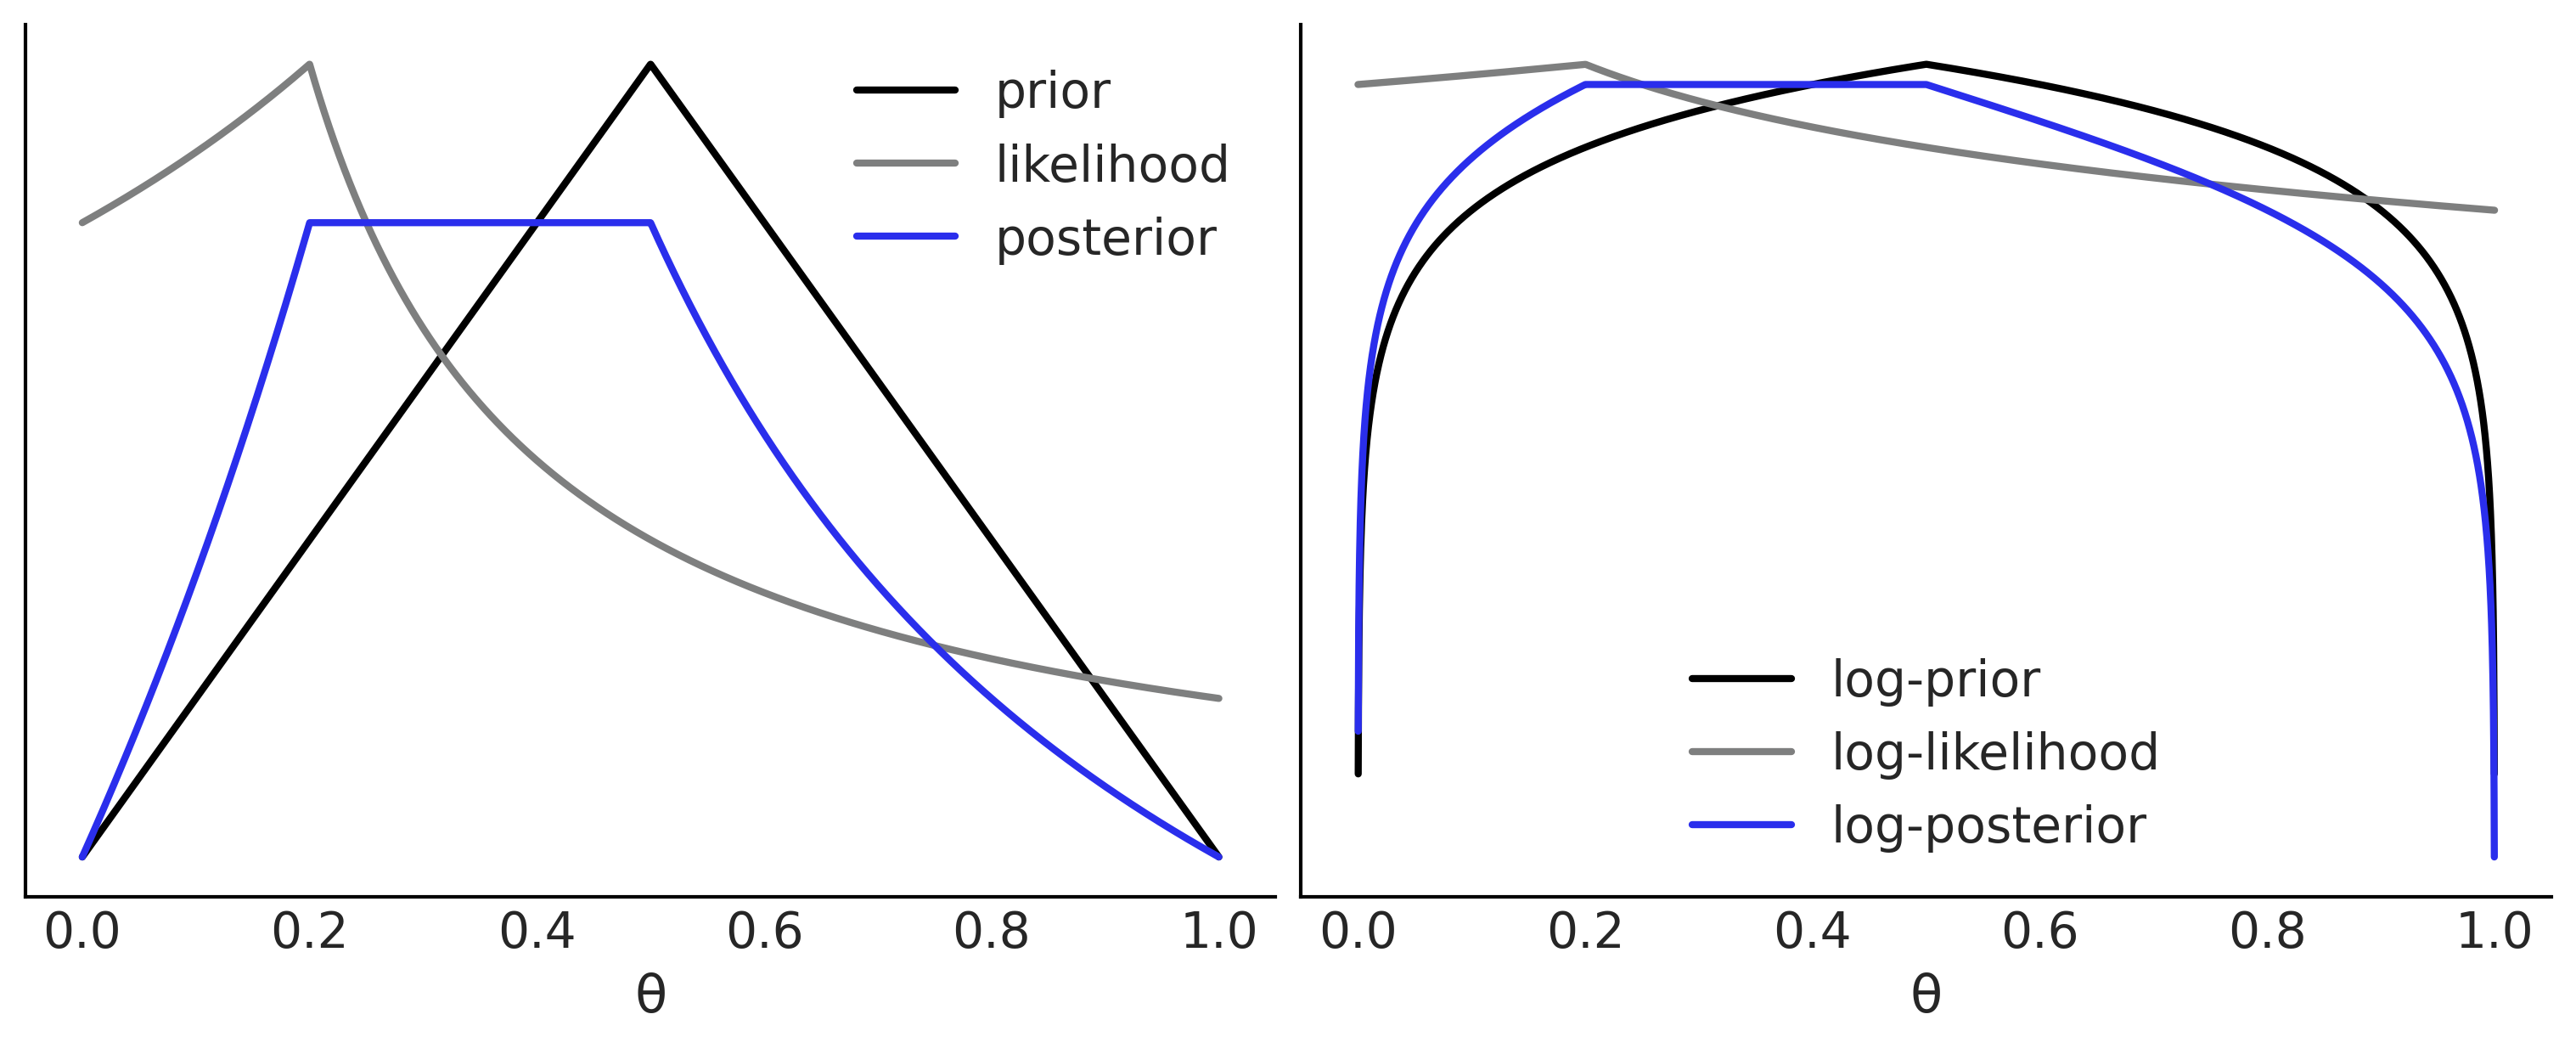

In [11]:
grid = np.linspace(0, 1, 5000)
prior = stats.triang.pdf(grid, 0.5)
likelihood = stats.triang.pdf(0.2, grid)
posterior = prior * likelihood
log_prior = np.log(prior)
log_likelihood = np.log(likelihood)
log_posterior = log_prior + log_likelihood

_, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(grid, prior, label="prior", lw=2)
ax[0].plot(grid, likelihood, label="likelihood", lw=2, color="C2")
ax[0].plot(grid, posterior, label="posterior", lw=2, color="C4")
ax[0].set_xlabel("θ")
ax[0].legend()
ax[0].set_yticks([])

ax[1].plot(grid, log_prior, label="log-prior", lw=2)
ax[1].plot(grid, log_likelihood, label="log-likelihood", lw=2, color="C2")
ax[1].plot(grid, log_posterior, label="log-posterior", lw=2, color="C4")
ax[1].set_xlabel("θ")
ax[1].legend()
ax[1].set_yticks([])
plt.show()

In [12]:
def post(θ, Y, α=1, β=1):
    if 0 <= θ <= 1:
        prior = stats.beta(α, β).pdf(θ)
        like  = stats.bernoulli(θ).pmf(Y).prod()
        prop = like * prior
    else:
        prop = -np.inf
    return prop

In [13]:
Y = stats.bernoulli(0.7).rvs(20)

n_iters = 1000
can_sd = 0.05
α = β =  1
θ = 0.5
trace = {'θ':np.zeros(n_iters)}
p2 = post(θ, Y, α, β)

for iter in range(n_iters):
    θ_can = stats.norm(θ, can_sd).rvs(1)
    p1 = post(θ_can, Y, α, β)
    pa = p1 / p2

    if pa > stats.uniform(0, 1).rvs(1):
        θ = θ_can
        p2 = p1

    trace['θ'][iter] = θ

az.summary(trace, kind='stats', round_to=2)

C:\Users\Hao\AppData\Local\Temp\ipykernel_15892\978859602.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trace['θ'][iter] = θ


,mean,sd,hdi_3%,hdi_97%
θ,0.69,0.1,0.51,0.87


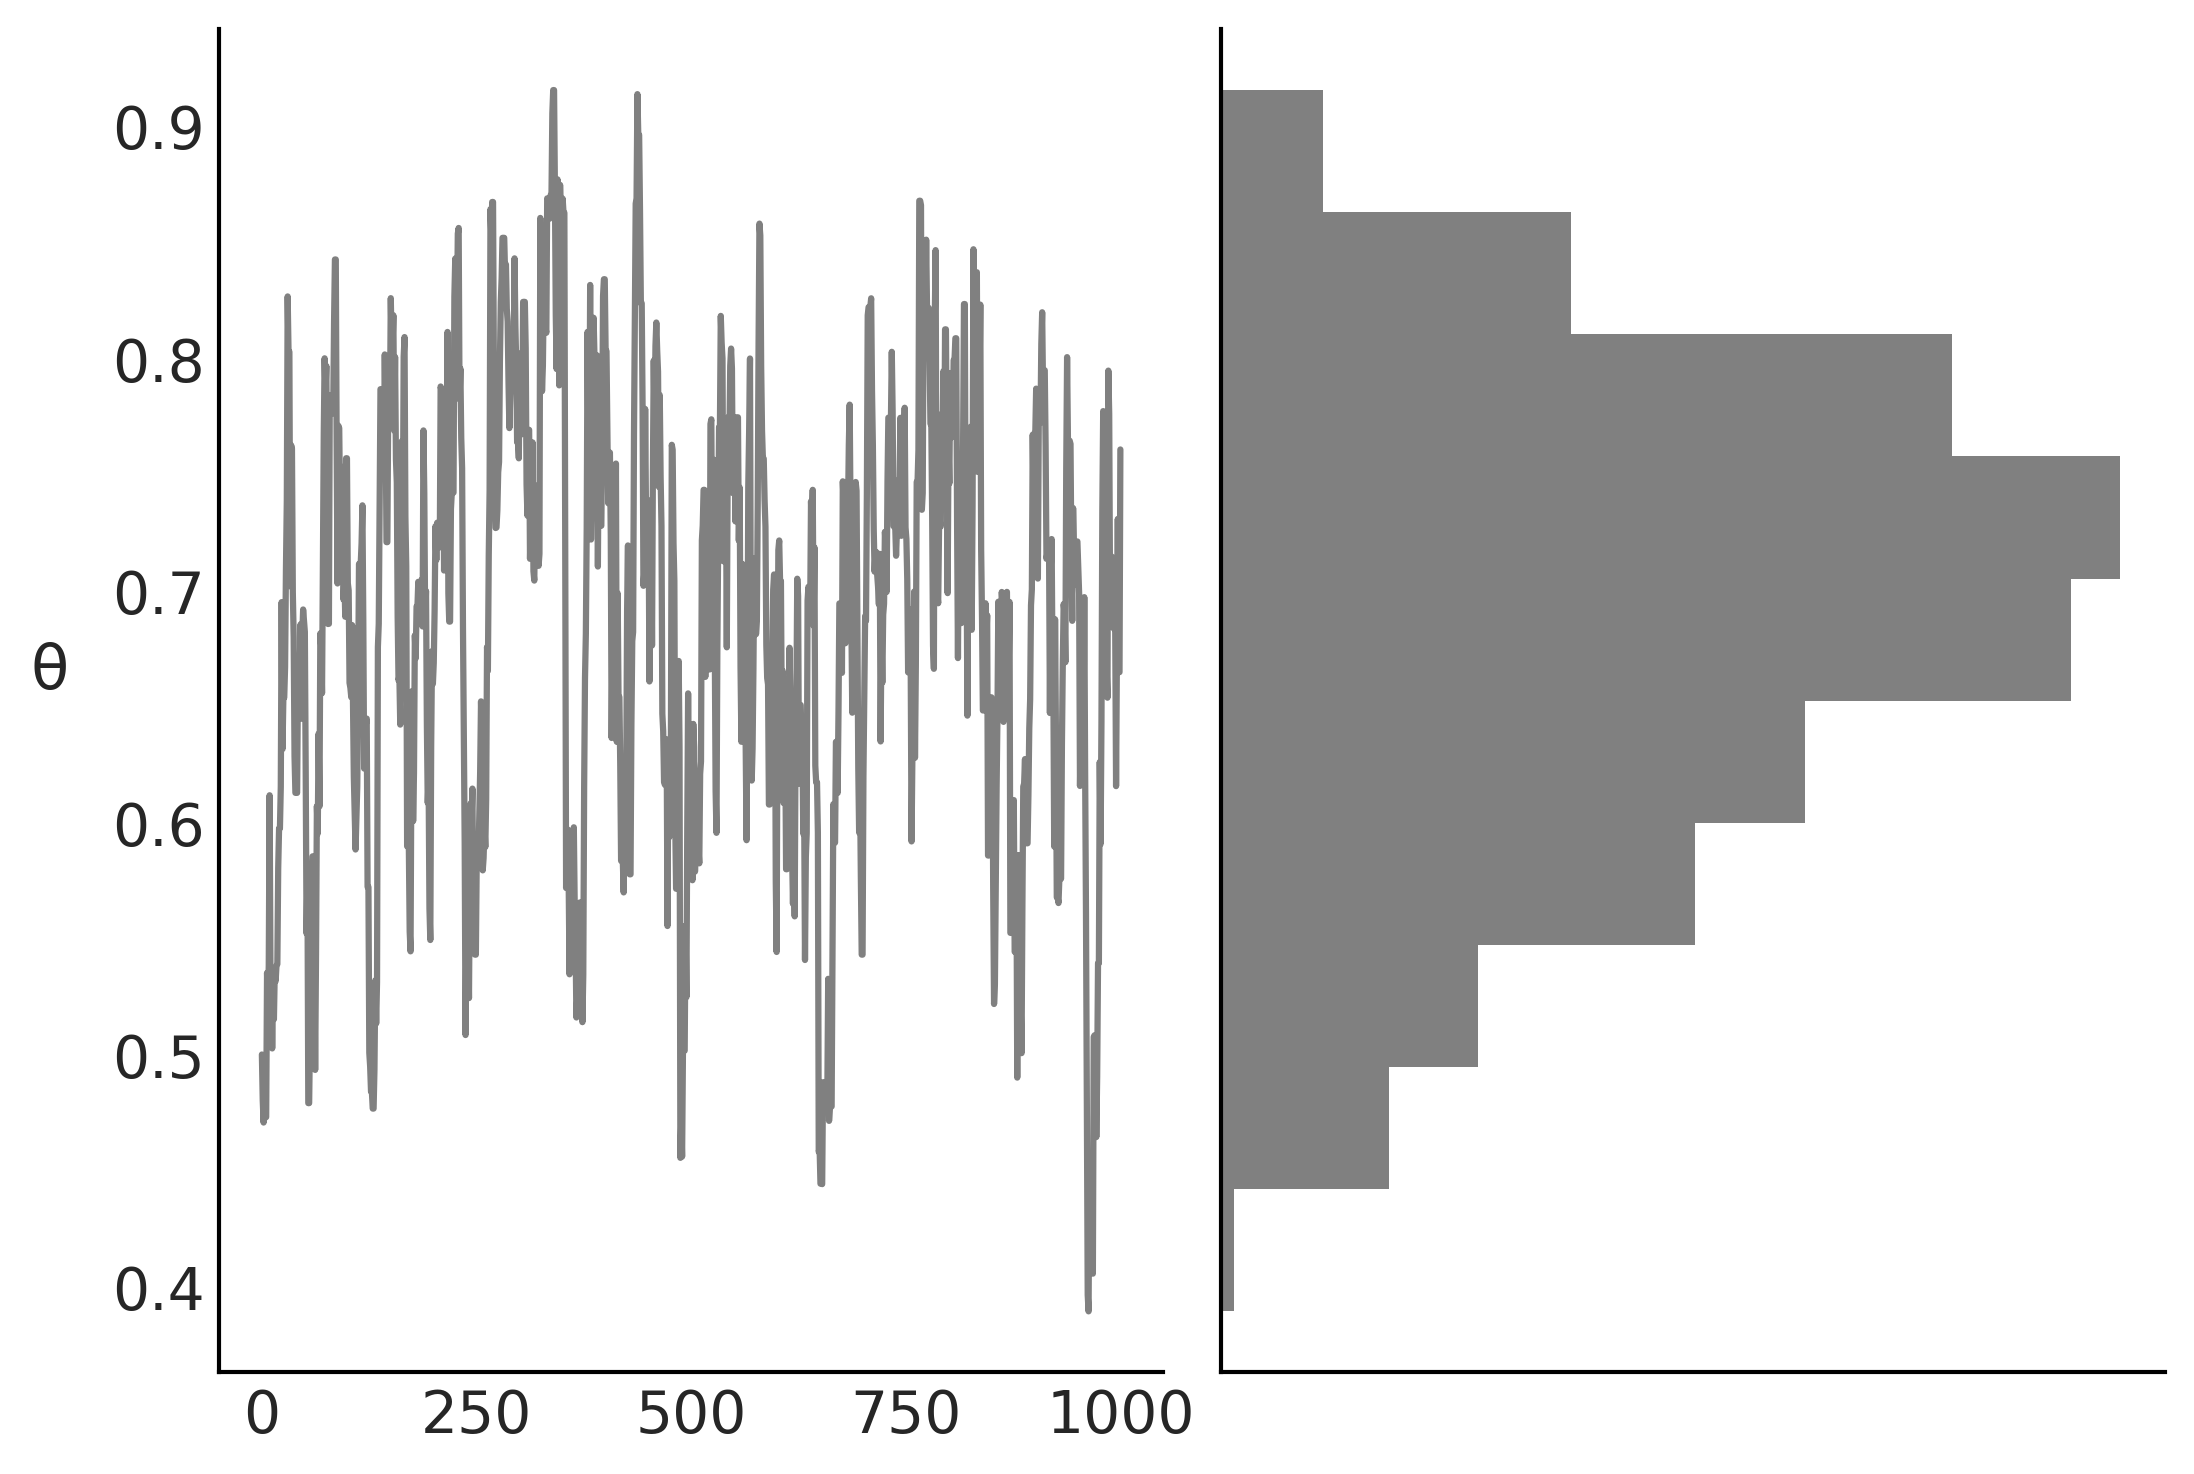

In [16]:
_, axes = plt.subplots(1,2, sharey=True)
axes[0].plot(trace['θ'], '0.5')
axes[0].set_ylabel('θ', rotation=0, labelpad=15)
axes[1].hist(trace['θ'], color='0.5', orientation="horizontal", density=True)
axes[1].set_xticks([])
plt.show()

In [17]:
# Declare a model in PyMC3
with pm.Model() as model:
    # Specify the prior distribution of unknown parameter
    θ = pm.Beta("θ", alpha=1, beta=1)

    # Specify the likelihood distribution and condition on the observed data
    y_obs = pm.Binomial("y_obs", n=1, p=θ, observed=Y)

    # Sample from the posterior distribution
    idata = pm.sample(1000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.
